In [1]:
# Bibliotheken laden
import pandas as pd
import numpy as np
import ast
import seaborn as sns
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.neural_network import MLPRegressor
from collections import Counter

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
# Konstanten
file_path = 'data.csv'
columns = [
    # 'id', 'name',

    # ── Gastgeber ─────────────────────────────────────────────────────────────
    'host_is_superhost',              # Erfahrener, hoch bewerteter Gastgeber – kann einen Preisaufschlag erzielen

    # ── Standort (wird später in Distanz zum Zentrum umgerechnet) ─────────────
    'latitude', 'longitude',          # Rohe Koordinaten → werden in Luftlinien-Entfernung zum Stadtzentrum umgerechnet

    # ── Unterkunftstyp & Größe ────────────────────────────────────────────────
    'room_type',                      # Ganze Wohnung vs. Privatzimmer – stärkster kategorialer Preistreiber
    'accommodates',                   # Maximale Gästezahl – wichtigstes Größenmerkmal und Preistreiber
    'bathrooms',                      # Mehr Badezimmer = größeres, hochwertigeres Objekt
    'bathrooms_text',                 # Rohtext zur Unterscheidung: geteiltes vs. privates Bad
    'bedrooms',                       # Anzahl der Schlafzimmer – ergänzt accommodates bei der Größeneinschätzung
    # 'beds' bewusst ausgeschlossen – Korrelation 0,805 mit accommodates (redundant)

    # ── Ausstattung ───────────────────────────────────────────────────────────
    'amenities',                      # Rohe Textliste → wird in amenity_count und binäre has_*-Flags umgewandelt

    # ── Zielvariable ──────────────────────────────────────────────────────────
    'price',                          # Nachtpreis in USD – die Variable, die wir vorhersagen wollen

    # ── Qualitäts- und Nachfragesignale ───────────────────────────────────────
    'review_scores_location',         # Von Gästen bewertete Lage (1–5); erfasst wahrgenommene Attraktivität
                                      # über den Stadtbezirk hinaus. Stärkeres Signal als review_scores_rating
                                      # (Korr. +0,132 vs. +0,032 mit dem Preis).
    'availability_365',               # Verfügbare Tage pro Jahr – Indikator für aktive Preisgestaltung

    # ── Geografie ─────────────────────────────────────────────────────────────
    'neighbourhood_cleansed',         # Standardisierter Londoner Stadtbezirk → wird in 33 binäre Spalten umkodiert

    # ── Professionalität des Gastgebers ───────────────────────────────────────
    'calculated_host_listings_count', # Anzahl aktiver Inserate dieses Gastgebers – unterscheidet professionelle
                                      # Betreiber (viele Inserate, strategische Preisgestaltung) von Privatpersonen.
                                      # Stärkstes ungenutztes Signal (Korr. +0,218 mit dem Preis).
]
# Quelle: https://www.latlong.net/place/london-uk-14153.html
london_center_lat = 51.509865
london_center_lon = -0.118092

# Zufalls-Seeds – das Modell wird einmal pro Seed trainiert und ausgewertet.
# Der Durchschnitt über alle Seeds liefert eine zuverlässigere Leistungsschätzung
# als ein einzelner Durchlauf.
seeds = [1, 7, 42, 67, 99]

In [3]:
# Rohdatensatz einlesen
df = pd.read_csv(file_path)

In [4]:
# Vollständige Ausgabe des DataFrames – nützlich zur ersten Übersicht
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

print(df.columns.tolist())
print(df.head())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availabil

In [5]:
# Nur relevante Spalten behalten und Zeilen mit fehlenden Werten entfernen
df = df[columns].dropna()

In [6]:
# Stadtbezirks-Spalte vor der Kodierung erkunden
print(df['neighbourhood_cleansed'].nunique())             # Wie viele einzigartige Stadtbezirke?
print(df['neighbourhood_cleansed'].value_counts().head(10))

33
neighbourhood_cleansed
Westminster               6240
Kensington and Chelsea    3505
Camden                    3419
Tower Hamlets             3284
Hackney                   2520
Southwark                 2412
Wandsworth                2336
Lambeth                   2245
Islington                 2179
Hammersmith and Fulham    2097
Name: count, dtype: int64


In [7]:
# One-Hot-Kodierung der Stadtbezirks-Spalte:
# Jeder Stadtbezirk erhält eine eigene 0/1-Spalte (z. B. nb_Westminster = 1, wenn das Inserat dort liegt).
nb_dummies = pd.get_dummies(df['neighbourhood_cleansed'], prefix='nb', dtype=int)
df = pd.concat([df, nb_dummies], axis=1)
df = df.drop(columns='neighbourhood_cleansed')

In [8]:
def calculate_haversine_distance(lat_series, lon_series, center_lat, center_lon):
    """
    Berechnet die Luftlinien-Entfernung (in Metern) zwischen jedem Inserat und einem festen Punkt.

    Verwendet die Haversine-Formel, die die Erdkrümmung korrekt berücksichtigt.
    Die Funktion ist vektorisiert – sie verarbeitet die gesamte Spalte auf einmal (sehr schnell).
    """
    R = 6371000.0  # Erdradius in Metern

    # Grad in Bogenmaß umrechnen (für trigonometrische Funktionen erforderlich)
    phi1         = np.radians(lat_series)
    phi2         = np.radians(center_lat)
    delta_phi    = np.radians(center_lat - lat_series)
    delta_lambda = np.radians(center_lon - lon_series)

    # Haversine-Formel
    a = np.sin(delta_phi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [9]:
# Rohe Koordinaten durch ein einzelnes Entfernungs-Feature ersetzen (in Metern zum Stadtzentrum)
df['distance_to_center_m'] = calculate_haversine_distance(
    df['latitude'], df['longitude'],
    london_center_lat, london_center_lon
).round()

df = df.drop(columns=['latitude', 'longitude'])

In [10]:
print(df.dtypes)

host_is_superhost                     str
room_type                             str
accommodates                        int64
bathrooms                         float64
bathrooms_text                        str
bedrooms                          float64
amenities                             str
price                                 str
review_scores_location            float64
availability_365                    int64
calculated_host_listings_count      int64
nb_Barking and Dagenham             int64
nb_Barnet                           int64
nb_Bexley                           int64
nb_Brent                            int64
nb_Bromley                          int64
nb_Camden                           int64
nb_City of London                   int64
nb_Croydon                          int64
nb_Ealing                           int64
nb_Enfield                          int64
nb_Greenwich                        int64
nb_Hackney                          int64
nb_Hammersmith and Fulham         

In [11]:
# Textwerte 't'/'f' in 1/0-Ganzzahlen umwandeln (1 = ist Superhost)
df['host_is_superhost'] = (df['host_is_superhost'] == 't').astype(int)

In [12]:
# Unterkunftstyp in vier separate 0/1-Spalten umkodieren (One-Hot-Encoding)
print(df['room_type'].unique())
df["is_private_room"] = (df["room_type"] == "Private room").astype(int)
df["is_entire_home"]  = (df["room_type"] == "Entire home/apt").astype(int)
df["is_hotel_room"]   = (df["room_type"] == "Hotel room").astype(int)
df["is_shared_room"]  = (df["room_type"] == "Shared room").astype(int)

df = df.drop(columns=['room_type'])

<StringArray>
['Private room', 'Entire home/apt', 'Hotel room', 'Shared room']
Length: 4, dtype: str


In [13]:
# Seltene Unterkunftstypen entfernen – Hotel (41 Inserate) und Shared (111 Inserate)
# sind zu wenige, um daraus verlässliche Muster zu lernen.
df = df[(df['is_hotel_room'] == False) & (df['is_shared_room'] == False)]
df = df.drop(columns=['is_hotel_room', 'is_shared_room'])

In [14]:
# Preisspalte bereinigen: '$'- und ','-Zeichen entfernen, dann in numerischen Float umwandeln
df['price_dollar'] = (df['price']
                      .str.replace("$", "", regex=False)
                      .str.replace(",", "", regex=False)
                      .str.replace(".00", "", regex=False)
                      .astype(float))
df = df.drop(columns=['price'])

In [15]:
# 1/0-Flag erstellen: 1 = geteiltes Bad, 0 = privates Bad
df['is_shared_bath'] = df['bathrooms_text'].str.contains('shared', case=False, na=False).astype(int)
df = df.drop(columns='bathrooms_text')

In [16]:
# Extreme Preisausreißer entfernen – Inserate über 1.000 $/Nacht sind wahrscheinlich Datenfehler
df = df[df['price_dollar'] < 1000]

In [17]:
# ── Extraktion der Ausstattungsmerkmale ───────────────────────────────────────
#
# Die rohe amenities-Spalte ist ein Text, der wie eine Python-Liste aussieht:
#   '["Wifi", "Kitchen", "Private pool", ...]'
#
# Daraus entstehen zwei Arten von Features:
#   1. amenity_count  – Gesamtanzahl der Ausstattungsmerkmale (mehr = hochwertigeres Inserat)
#   2. has_*          – Binäres Flag für relevante Einzelmerkmale
#
# has_wifi (98,3 %) und has_kitchen (91,5 %) wurden entfernt –
# quasi-konstante Features liefern kaum Information und verschwenden Modellkapazität.

def parse_amenities(val):
    """Den Amenities-Text in eine Python-Liste umwandeln."""
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return []
    return []

amenities_lists = df['amenities'].apply(parse_amenities)

# Gesamtanzahl der Ausstattungsmerkmale pro Inserat
df['amenity_count'] = amenities_lists.apply(len)

# Gezielte binäre Flags – Groß-/Kleinschreibung wird ignoriert, um Varianten wie
# "Private pool", "Patio or balcony" oder "Hot tub/Jacuzzi" zu erfassen.
targeted_amenities = {
    'has_pool':    lambda lst: any('pool' in a.lower() for a in lst),
    'has_hot_tub': lambda lst: any('hot tub' in a.lower() or 'jacuzzi' in a.lower() for a in lst),
    'has_bathtub': lambda lst: any('bathtub' in a.lower() for a in lst),
    'has_balcony': lambda lst: any('balcony' in a.lower() or 'patio' in a.lower() for a in lst),
}

for col, check in targeted_amenities.items():
    df[col] = amenities_lists.apply(check).astype(int)
    n = df[col].sum()
    print(f"{col:<15} {n:>6,} Inserate  ({n / len(df) * 100:.1f}%)")

print(f"\namenity_count:  Mittelwert={df['amenity_count'].mean():.1f}  "
      f"Min={df['amenity_count'].min()}  Max={df['amenity_count'].max()}")

# Rohe Textspalte entfernen – alle Informationen wurden bereits extrahiert
df = df.drop(columns='amenities')

has_pool           538 Inserate  (1.2%)


has_hot_tub        858 Inserate  (1.9%)
has_bathtub     21,203 Inserate  (45.8%)


has_balcony     11,601 Inserate  (25.1%)

amenity_count:  Mittelwert=33.4  Min=0  Max=96


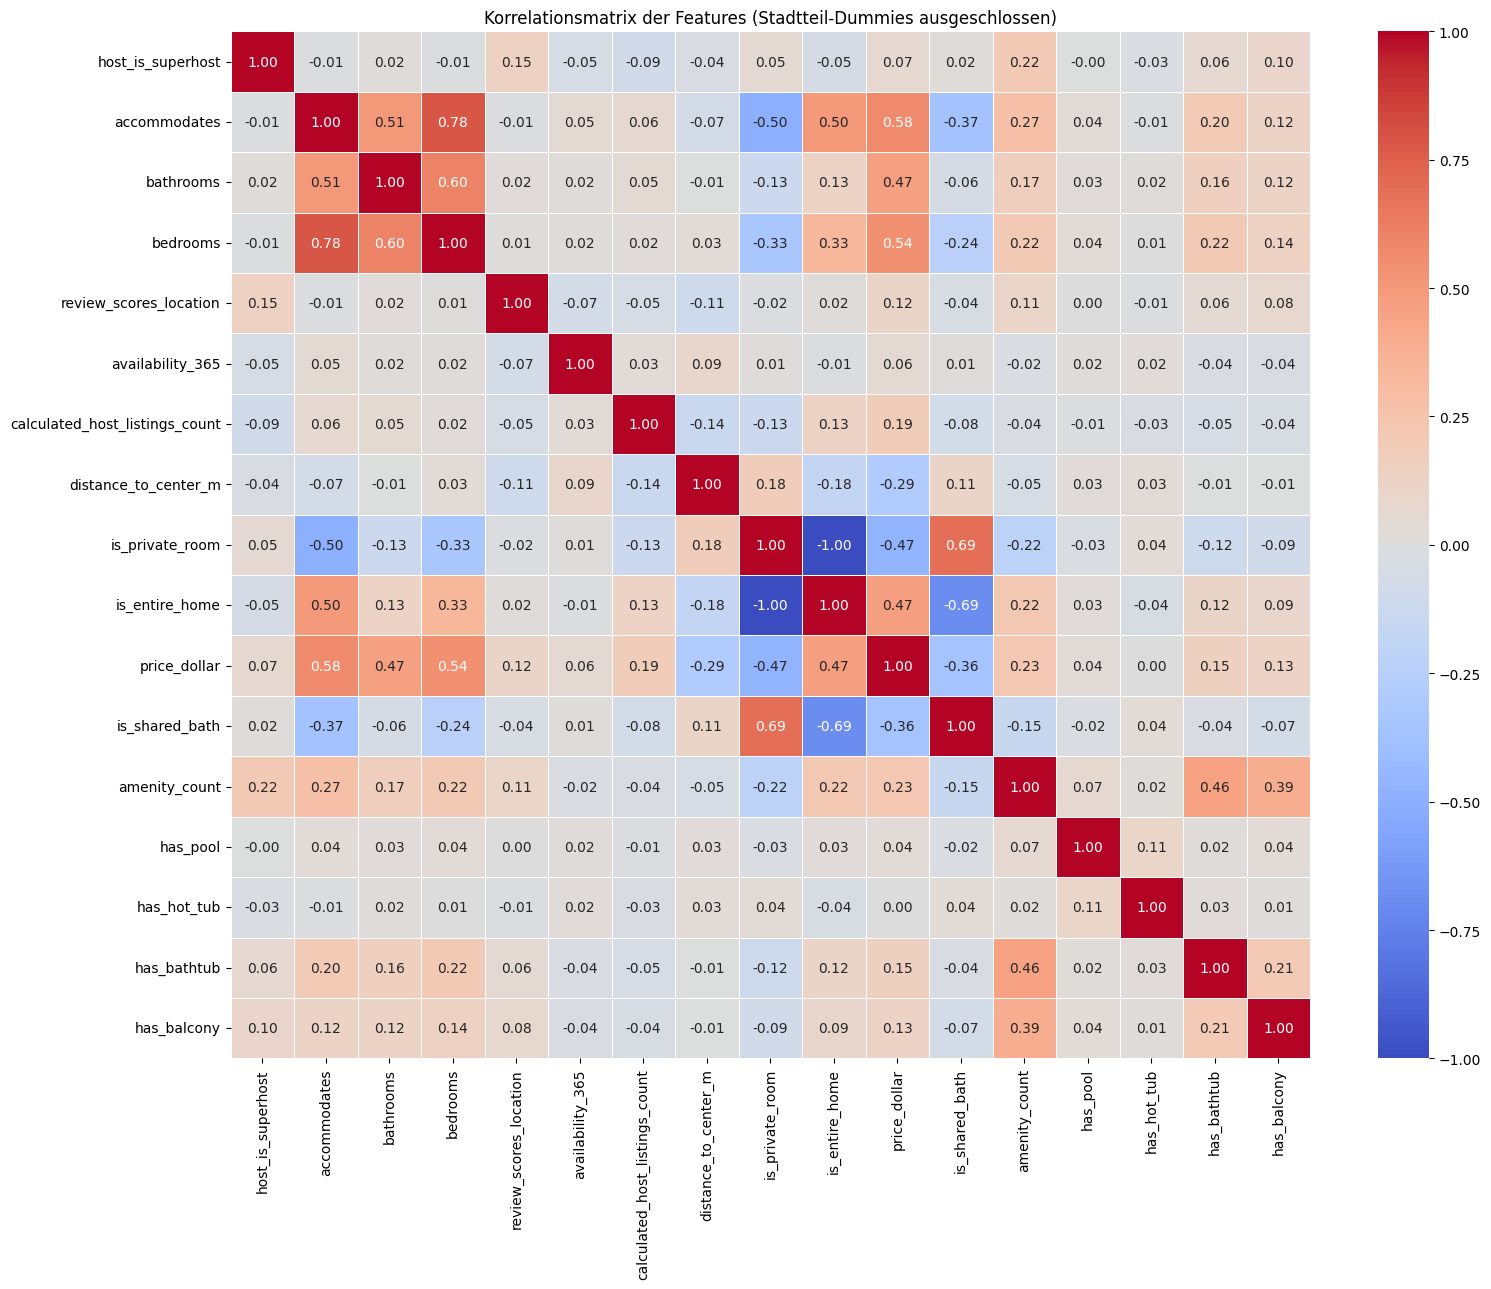

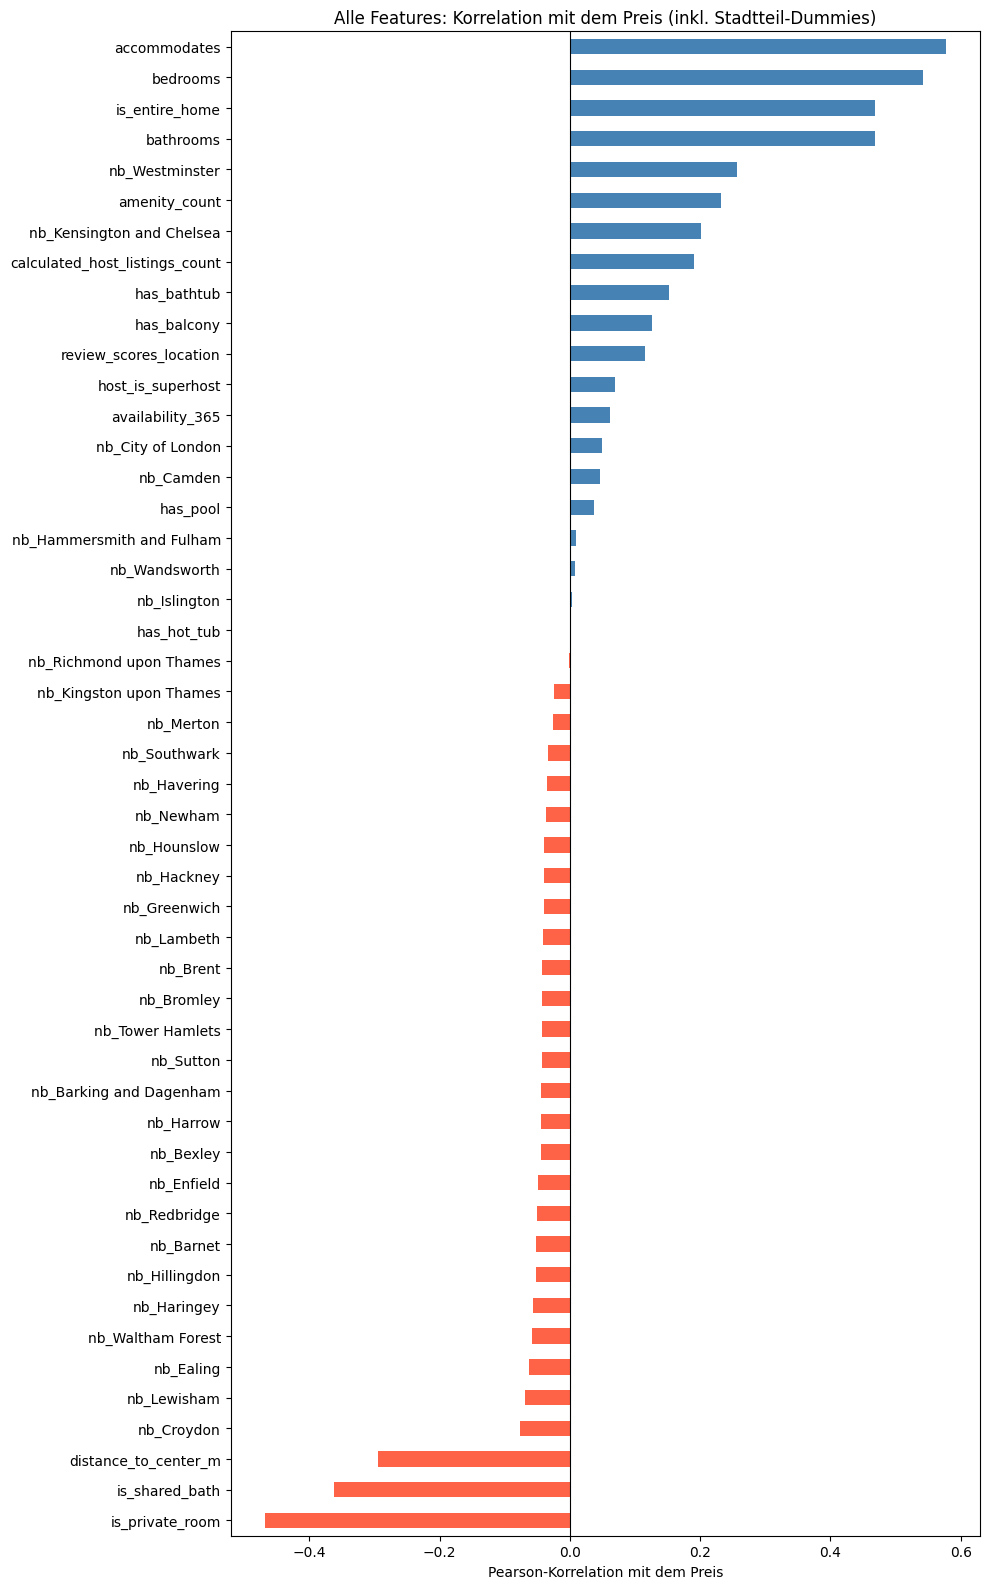

In [18]:
# ── Korrelationsanalyse der Features ──────────────────────────────────────────
#
# Diagramm 1 – Heatmap aller erstellten Features (Stadtteil-Dummies ausgeschlossen).
#   Die 33 nb_*-Spalten sind One-Hot-kodiert und schließen sich gegenseitig aus.
#   Ihre Kreuzkorrelationen sind daher nichtssagend und würden die Matrix unleserlich machen.
#
# Diagramm 2 – Balkendiagramm der Korrelation ALLER Features mit dem Preis,
#   einschließlich der Stadtteil-Dummies. Zeigt, welche Stadtbezirke den Preis erhöhen oder senken.

non_dummy_cols = [c for c in df.columns if not c.startswith('nb_')]
corr_matrix = df[non_dummy_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    ax=ax,
)
ax.set_title('Korrelationsmatrix der Features (Stadtteil-Dummies ausgeschlossen)')
plt.tight_layout()
plt.show()

# ── Alle Features vs. Preis (inkl. Stadtteil-Dummies) ────────────────────────
price_corr = df.corr(numeric_only=True)['price_dollar'].drop('price_dollar').sort_values()

colors = ['tomato' if v < 0 else 'steelblue' for v in price_corr]
fig, ax = plt.subplots(figsize=(10, 16))
price_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson-Korrelation mit dem Preis')
ax.set_title('Alle Features: Korrelation mit dem Preis (inkl. Stadtteil-Dummies)')
plt.tight_layout()
plt.show()

In [19]:
# ── Features und Zielvariable vorbereiten ─────────────────────────────────────
X = df.drop(columns='price_dollar')
y = np.log1p(df['price_dollar'])  # Log-Transformation: gleicht die schiefe Preisverteilung aus

# ── Hyperparameter-Optimierung mit Optuna (erster Seed) ───────────────────────
# Aufteilung: 80 % Training, 20 % Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seeds[0])

# Features standardisieren: Mittelwert abziehen, durch Standardabweichung teilen.
# Wichtig: Scaler nur auf Trainingsdaten anpassen – verhindert Datenleck in den Testbereich.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Trainingsdaten nochmals aufteilen: Train/Validierung für Optuna's Early Stopping
X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=seeds[0])

def objective(trial):
    """
    Optuna ruft diese Funktion einmal pro Versuch auf.
    Es wird ein XGBoost-Modell mit vorgeschlagenen Hyperparametern trainiert.
    Der zurückgegebene Validierungs-RMSE wird von Optuna minimiert.
    """
    params = {
        'n_estimators':          1000,
        'early_stopping_rounds': 50,        # Abbruch, wenn sich der Val-RMSE nicht mehr verbessert
        'eval_metric':           'rmse',
        'learning_rate':         trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':             trial.suggest_int('max_depth', 3, 10),
        'subsample':             trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':      trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':      trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':             trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':            trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state':          seeds[0],
        'verbosity':             0,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)
    return root_mean_squared_error(y_val, preds)

# Hyperparameter-Suche starten (n_trials erhöhen für bessere Ergebnisse)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print(f"Bester Val-RMSE  : {study.best_value:.4f}")
print(f"Beste Parameter  : {study.best_params}")

# ── Auswertung über mehrere Seeds ─────────────────────────────────────────────
# Das Modell wird mit den besten Hyperparametern auf verschiedenen zufälligen Aufteilungen
# neu trainiert. Der Durchschnitt über alle Seeds liefert eine zuverlässigere Schätzung
# der realen Leistung als eine einzelne Aufteilung.
best_params = study.best_params | {
    'n_estimators':          1000,
    'early_stopping_rounds': 50,
    'eval_metric':           'rmse',
    'verbosity':             0,
}

rmse_scores = []

for seed in seeds:
    # Neue Train/Test-Aufteilung für diesen Seed
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.2, random_state=seed)

    # Scaler nur auf Trainingsdaten anpassen (verhindert Datenleck)
    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled  = scaler_s.transform(X_test_s)

    # Validierungsaufteilung für Early Stopping
    X_tr_s, X_val_s, y_tr_s, y_val_s = train_test_split(
        X_train_s_scaled, y_train_s, test_size=0.2, random_state=seed
    )

    # Modell mit den besten Optuna-Hyperparametern trainieren
    model = xgb.XGBRegressor(**best_params, random_state=seed)
    model.fit(X_tr_s, y_tr_s, eval_set=[(X_val_s, y_val_s)], verbose=False)

    # Log-Vorhersagen zurück in Dollarwerte umrechnen und RMSE berechnen
    y_pred_s = np.expm1(model.predict(X_test_s_scaled))
    y_true_s = np.expm1(y_test_s)
    rmse_s   = root_mean_squared_error(y_true_s, y_pred_s)

    rmse_scores.append(rmse_s)
    print(f"Seed {seed:>3}: Test-RMSE = ${rmse_s:.2f}")

print(f"\nMittlerer RMSE : ${np.mean(rmse_scores):.2f}  ±  ${np.std(rmse_scores):.2f}")

# Letztes trainiertes Modell für die Feature-Importance-Diagramme behalten
final_model = model

Bester Val-RMSE  : 0.3072
Beste Parameter  : {'learning_rate': 0.022432326428083665, 'max_depth': 10, 'subsample': 0.9944042589352959, 'colsample_bytree': 0.5215245442766728, 'min_child_weight': 6, 'reg_alpha': 1.179928116197137e-06, 'reg_lambda': 0.0325116197094205}


Seed   1: Test-RMSE = $72.21


Seed   7: Test-RMSE = $70.15


Seed  42: Test-RMSE = $69.55


Seed  67: Test-RMSE = $72.78


Seed  99: Test-RMSE = $74.20

Mittlerer RMSE : $71.78  ±  $1.71


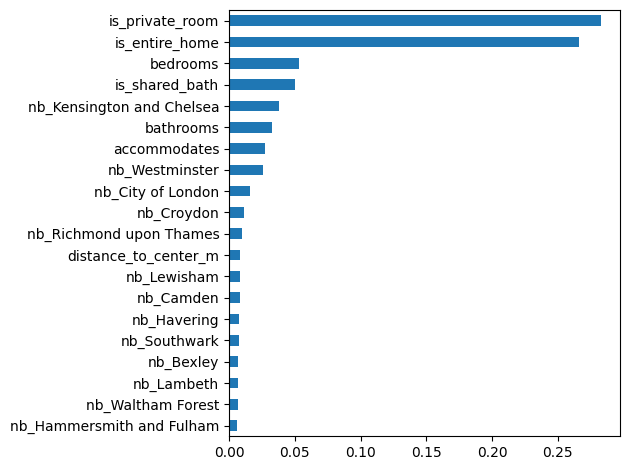

In [20]:
importances = pd.Series(final_model.feature_importances_, index=X.columns)
importances.sort_values().tail(20).plot(kind='barh')
plt.tight_layout()
plt.show()

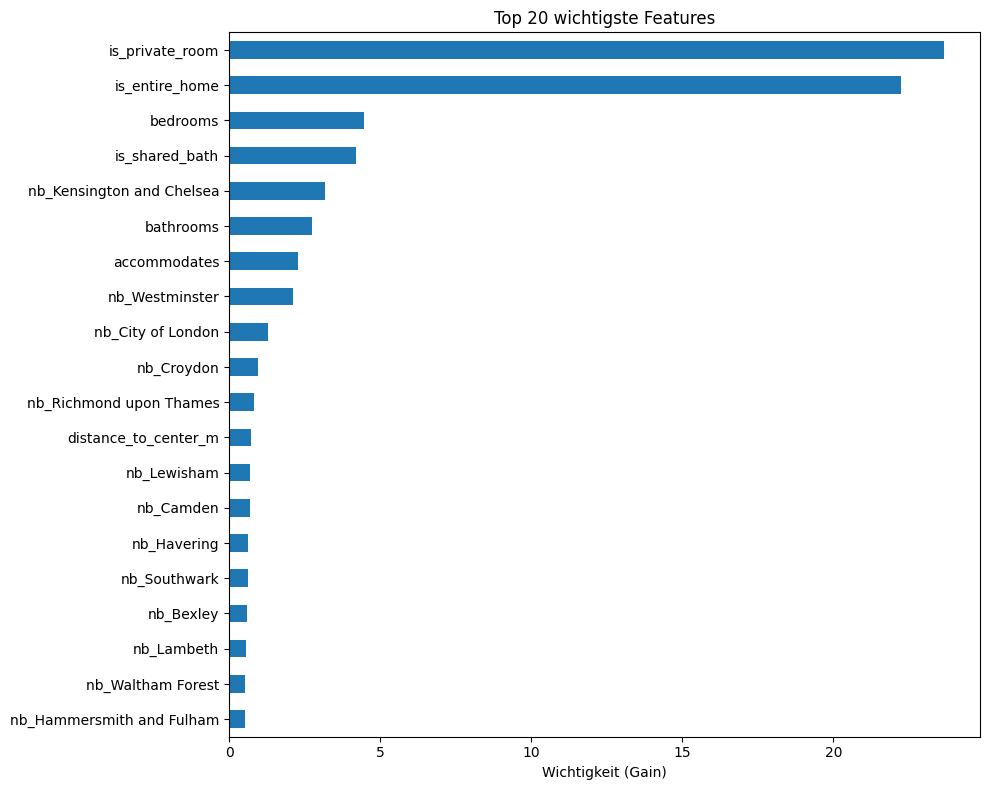

In [21]:
# Feature-Importance nach "Gain" – durchschnittliche Reduktion des Vorhersagefehlers pro Feature.
# Aussagekräftiger als die Standard-"Weight"-Metrik, die nur Verzweigungen zählt.
booster = final_model.get_booster()
booster.feature_names = list(X.columns)

importance_dict = booster.get_score(importance_type='gain')
importances = pd.Series(importance_dict).sort_values()

importances.tail(20).plot(kind='barh', figsize=(10, 8))
plt.xlabel('Wichtigkeit (Gain)')
plt.title('Top 20 wichtigste Features')
plt.tight_layout()
plt.show()

In [22]:
# ── Lineare Regression ────────────────────────────────────────────────────────
# Einfachstes Basismodell: nimmt einen linearen Zusammenhang zwischen jedem Feature
# und dem (log-)Preis an. Keine Hyperparameter zu optimieren.

rmse_lr = []

for seed in seeds:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.2, random_state=seed)

    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled  = scaler_s.transform(X_test_s)

    model_lr = LinearRegression()
    model_lr.fit(X_train_s_scaled, y_train_s)

    y_pred = np.expm1(model_lr.predict(X_test_s_scaled))
    y_true = np.expm1(y_test_s)
    rmse   = root_mean_squared_error(y_true, y_pred)

    rmse_lr.append(rmse)
    print(f"Seed {seed:>3}: Test-RMSE = ${rmse:.2f}")

print(f"\nLineare Regression   —  Mittlerer RMSE: ${np.mean(rmse_lr):.2f}  ±  ${np.std(rmse_lr):.2f}")

Seed   1: Test-RMSE = $85.05
Seed   7: Test-RMSE = $84.21
Seed  42: Test-RMSE = $82.94
Seed  67: Test-RMSE = $93.73
Seed  99: Test-RMSE = $87.49

Lineare Regression   —  Mittlerer RMSE: $86.68  ±  $3.82


In [23]:
# ── Ridge-Regression ──────────────────────────────────────────────────────────
# Wie lineare Regression, aber mit L2-Strafterm, der große Koeffizienten verkleinert.
# Reduziert Überanpassung bei korrelierten Features (z. B. unsere Stadtteil-Dummies).
# RidgeCV wählt die optimale Stärke (Alpha) automatisch per 5-facher Kreuzvalidierung.

ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

rmse_ridge = []

for seed in seeds:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.2, random_state=seed)

    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled  = scaler_s.transform(X_test_s)

    model_ridge = RidgeCV(alphas=ALPHAS, cv=5)
    model_ridge.fit(X_train_s_scaled, y_train_s)

    y_pred = np.expm1(model_ridge.predict(X_test_s_scaled))
    y_true = np.expm1(y_test_s)
    rmse   = root_mean_squared_error(y_true, y_pred)

    rmse_ridge.append(rmse)
    print(f"Seed {seed:>3}: Test-RMSE = ${rmse:.2f}  (bestes Alpha = {model_ridge.alpha_})")

print(f"\nRidge-Regression     —  Mittlerer RMSE: ${np.mean(rmse_ridge):.2f}  ±  ${np.std(rmse_ridge):.2f}")

Seed   1: Test-RMSE = $85.05  (bestes Alpha = 10.0)


Seed   7: Test-RMSE = $84.21  (bestes Alpha = 10.0)


Seed  42: Test-RMSE = $82.94  (bestes Alpha = 10.0)


Seed  67: Test-RMSE = $93.73  (bestes Alpha = 10.0)


Seed  99: Test-RMSE = $87.49  (bestes Alpha = 10.0)

Ridge-Regression     —  Mittlerer RMSE: $86.69  ±  $3.82


In [24]:
# ── Neuronales Netz ───────────────────────────────────────────────────────────
# Ein mehrschichtiges Perzeptron (MLP) mit drei verdeckten Schichten.
# Es lernt nichtlineare Merkmalskombinationen – ausdrucksstärker als lineare Modelle,
# aber auch langsamer im Training.
#
# Architektur:  Eingabe → 256 → 128 → 64 → Ausgabe
#
# early_stopping=True reserviert 10 % der Trainingsdaten zur internen Validierung
# und stoppt das Training, wenn keine Verbesserung mehr eintritt (verhindert Überanpassung).

rmse_nn = []

for seed in seeds:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.2, random_state=seed)

    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled  = scaler_s.transform(X_test_s)

    model_nn = MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=seed,
        verbose=False,
    )
    model_nn.fit(X_train_s_scaled, y_train_s)

    y_pred = np.expm1(model_nn.predict(X_test_s_scaled))
    y_true = np.expm1(y_test_s)
    rmse   = root_mean_squared_error(y_true, y_pred)

    rmse_nn.append(rmse)
    print(f"Seed {seed:>3}: Test-RMSE = ${rmse:.2f}")

print(f"\nNeuronales Netz      —  Mittlerer RMSE: ${np.mean(rmse_nn):.2f}  ±  ${np.std(rmse_nn):.2f}")

Seed   1: Test-RMSE = $79.53


Seed   7: Test-RMSE = $77.91


Seed  42: Test-RMSE = $79.78


Seed  67: Test-RMSE = $92.56


Seed  99: Test-RMSE = $83.13

Neuronales Netz      —  Mittlerer RMSE: $82.58  ±  $5.27


Modell                  Mittl. RMSE ($)    Std ($)
──────────────────────────────────────────────────
XGBoost                $         71.78   ±$  1.71
Neuronales Netz        $         82.58   ±$  5.27
Lineare Regression     $         86.68   ±$  3.82
Ridge-Regression       $         86.69   ±$  3.82


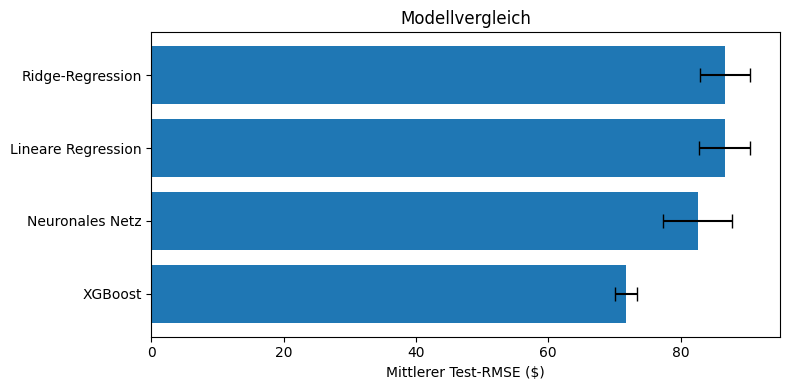

In [25]:
# ── Modellvergleich ───────────────────────────────────────────────────────────
# Übersicht aller Modelle, sortiert nach mittlerem RMSE (kleiner = besser).

results = {
    'Lineare Regression': rmse_lr,
    'Ridge-Regression':   rmse_ridge,
    'Neuronales Netz':    rmse_nn,
    'XGBoost':            rmse_scores,
}

print(f"{'Modell':<22} {'Mittl. RMSE ($)':>16} {'Std ($)':>10}")
print("─" * 50)
for name, scores in sorted(results.items(), key=lambda x: np.mean(x[1])):
    print(f"{name:<22} ${np.mean(scores):>14.2f}   ±${np.std(scores):>6.2f}")

# Balkendiagramm zum visuellen Vergleich
means = [np.mean(v) for v in results.values()]
stds  = [np.std(v)  for v in results.values()]
names = list(results.keys())

order = np.argsort(means)
plt.figure(figsize=(8, 4))
plt.barh(
    [names[i] for i in order],
    [means[i] for i in order],
    xerr=[stds[i] for i in order],
    capsize=5,
)
plt.xlabel('Mittlerer Test-RMSE ($)')
plt.title('Modellvergleich')
plt.tight_layout()
plt.show()

Modell                  Vorher ($) Nachher ($)  Änderung
──────────────────────────────────────────────────────────
XGBoost                  $   74.92   $   71.78   ▼ 3.14
Neuronales Netz          $   84.40   $   82.58   ▼ 1.82
Lineare Regression       $   87.85   $   86.68   ▼ 1.17
Ridge-Regression         $   87.85   $   86.69   ▼ 1.16


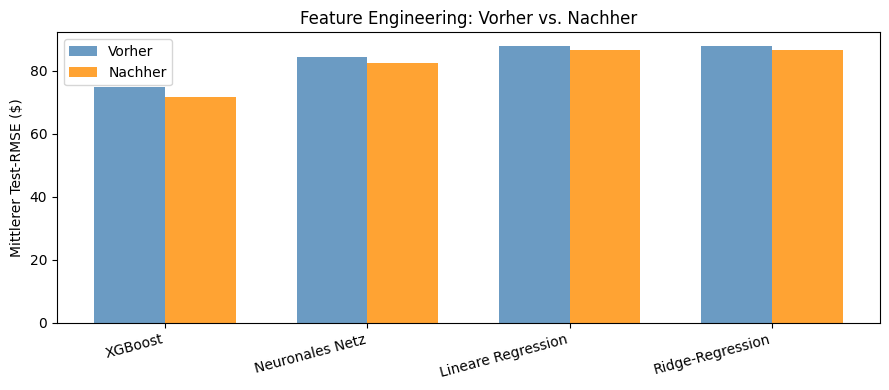

In [26]:
# ── Vorher vs. Nachher: Einfluss des Feature Engineerings ─────────────────────
# Diese Basiswerte wurden VOR den Feature-Verbesserungen aufgezeichnet:
#   - enthielt has_wifi (98,3 % konstant) und has_kitchen (91,5 % konstant)
#   - enthielt beds (Korr. 0,805 mit accommodates – redundant)
#   - verwendete review_scores_rating (Korr. +0,032) statt review_scores_location (+0,132)
#   - fehlte calculated_host_listings_count (Korr. +0,218, stärkstes ungenutztes Signal)

baseline = {
    'XGBoost':            74.92,
    'Neuronales Netz':    84.40,
    'Lineare Regression': 87.85,
    'Ridge-Regression':   87.85,
}
after = {
    'XGBoost':            np.mean(rmse_scores),
    'Neuronales Netz':    np.mean(rmse_nn),
    'Lineare Regression': np.mean(rmse_lr),
    'Ridge-Regression':   np.mean(rmse_ridge),
}

print(f"{'Modell':<22} {'Vorher ($)':>11} {'Nachher ($)':>11} {'Änderung':>9}")
print("─" * 58)
for name in ['XGBoost', 'Neuronales Netz', 'Lineare Regression', 'Ridge-Regression']:
    b, a = baseline[name], after[name]
    delta = a - b
    tag = f"{'▼' if delta < 0 else '▲'} {abs(delta):.2f}"
    print(f"{name:<22}   ${b:>8.2f}   ${a:>8.2f}   {tag}")

# Gruppiertes Balkendiagramm
models = list(baseline.keys())
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width / 2, [baseline[m] for m in models], width, label='Vorher',  color='steelblue',  alpha=0.8)
ax.bar(x + width / 2, [after[m]    for m in models], width, label='Nachher', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('Mittlerer Test-RMSE ($)')
ax.set_title('Feature Engineering: Vorher vs. Nachher')
ax.legend()
plt.tight_layout()
plt.show()